In [191]:
%pip install scipy
%pip install statsmodels
%pip install scikit-learn

from scipy import stats
import numpy as np
import matplotlib.pyplot as plt
import math
import statsmodels.api as sm
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


# A

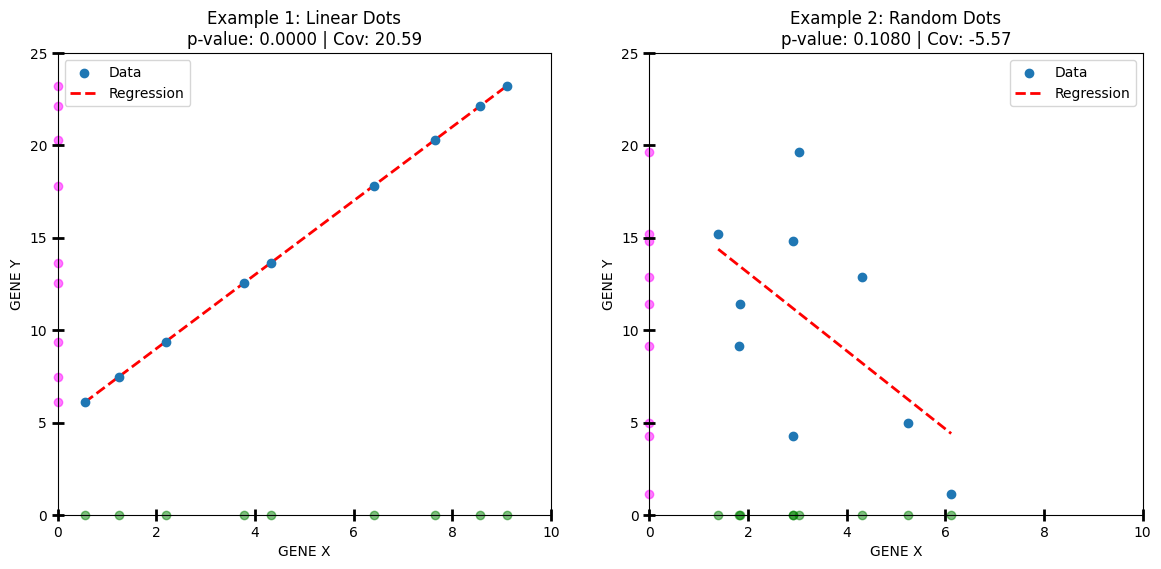

In [192]:
#plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

def processar_grafico(ax, x, y, title):
    #linear regression
    res = stats.linregress(x, y)
    
    #covariance
    cov_matrix = np.cov(x, y)
    cov_val = cov_matrix[0, 1]

    #p value
    p_value = res.pvalue

    #dots and projections
    ax.scatter(x, y, zorder=3, label='Data')
    ax.scatter(x, [0]*len(x), color='green', alpha=0.5, clip_on=False)
    ax.scatter([0]*len(y), y, color='magenta', alpha=0.5, clip_on=False)

    #linear regression line
    lx = np.linspace(min(x), max(x), 100)
    ly = res.slope * lx + res.intercept
    ax.plot(lx, ly, color='red', linestyle='--', linewidth=2, label='Regression')

    #plot config
    ax.set_title(f"{title}\np-value: {p_value:.4f} | Cov: {cov_val:.2f}")

    ax.set_xlabel("GENE X")
    ax.set_ylabel("GENE Y")
    ax.set_xlim(0, 10); ax.set_ylim(0, 25)
    ax.tick_params(direction='inout', length=8, width=2)
    ax.legend()


#FIRST GRAPH
#data [0, 10]
x1 = [1.24, 8.57, 4.32, 0.55, 9.12, 3.78, 6.41, 2.19, 7.65]
y1 = [7.48, 22.14, 13.64, 6.10, 23.24, 12.56, 17.82, 9.38, 20.30]

processar_grafico(ax1, x1, y1, "Example 1: Linear Dots")

#SECOND GRAPH (RANDOM)
#data [0, 10]
x2 = np.random.uniform(0, 10, 9)
y2 = np.random.uniform(0, 25, 9)

processar_grafico(ax2, x2, y2, "Example 2: Random Dots")

# Interpretação dos dados da questão A:

* **Função linregress**:
    * Encontra a reta que melhor representa os dados.

* **P-Value**:
    * **Gráfico 1 (Linear)**: O p-value é 0, ou seja, a relação entre os dados é real e significativa.
    * **Gráfico 2 (Aleatório)**: O p-value normalmente é alto (maior que 0.05), ou seja, a reta é apenas uma coincidência e os dados não têm relação entre si.

* **Covariância**:
    * A covariância mede se os genes (X e Y) variam juntos e em qual direção.
    * Se a covariância estiver mais perto de 0, menor é a relação entre os genes e mais dificíl de prever resultados.

---

# B

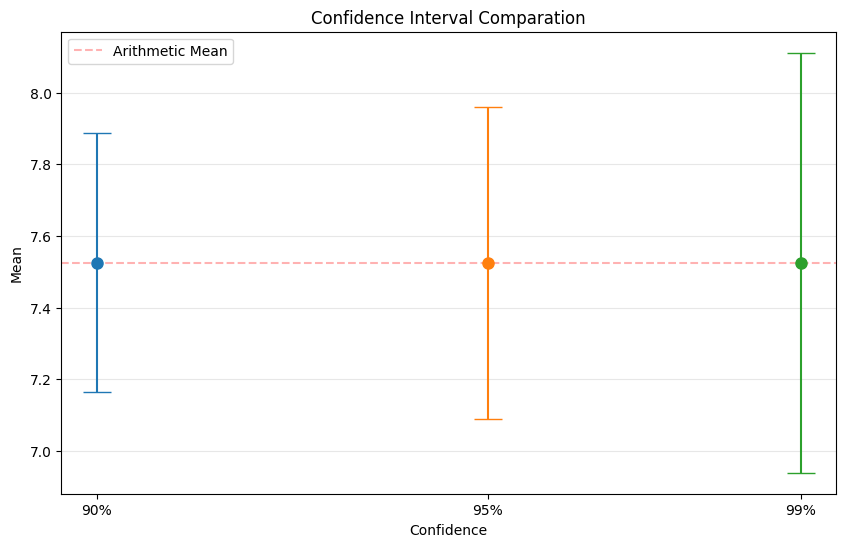

In [193]:
#seed
rng = np.random.default_rng(42)

#data, arithmetic mean and standard deviation
data = rng.normal(loc=7.5, scale=1.5, size=30)
arithmetic_mean = np.mean(data)
standard_deviation = np.std(data, ddof=1)

#confidences intervals
n = len(data)
confidences = [0.90, 0.95, 0.99]
intervals = []

for conf in confidences:
    interval = stats.t.interval(conf, df=n-1, loc=arithmetic_mean, scale=stats.sem(data))
    intervals.append(interval)

#error bars
plt.figure(figsize=(10, 6))
for i, (conf, inter) in enumerate(zip(confidences, intervals)):
    error = (inter[1] - inter[0]) / 2
    plt.errorbar(conf, arithmetic_mean, yerr=error, fmt='o', capsize=10,  markersize=8)

#plot config
plt.axhline(arithmetic_mean, color='red', linestyle='--', alpha=0.3, label='Arithmetic Mean')
plt.title('Confidence Interval Comparation')
plt.xlabel('Confidence')
plt.ylabel('Mean')
plt.xticks(confidences, ['90%', '95%', '99%'])
plt.legend()
plt.grid(axis='y', alpha=0.3)

plt.show()

---

# C

In [194]:
rng = np.random.default_rng(10)
control = rng.normal(loc=15.2, scale=2.1, size=30)
test = rng.normal(loc=17.5, scale=2.5, size=30)

print(f"Control Mean: {np.mean(control):.2f}")
print(f"Test Mean: {np.mean(test):.2f}")

t_stat, p_value = stats.ttest_ind(control, test)

print(f"T statistic: {t_stat:.6f}")
print(f"P-value: {p_value:.6f}")

Control Mean: 14.63
Test Mean: 17.08
T statistic: -4.927991
P-value: 0.000007


* **Parâmetros:**
    * **Nível de Significância ($\alpha$):** 0,05 (limite de erro aceitável).
    * **P-value obtido:** 0.000007 (probabilidade do resultado ser coincidência).
    * **Estatística t:** -4.9280 (diferença em relação à margem de erro).

* **Análise:**
    O P-value de 0.000007 mostra que a chance de a diferença entre as médias ser coincidência é quase nula. Como este valor é muito menor que o $\alpha$ de 0.05, o resultado é  significativo.
    
* **Hipótese Nula ($H_0$):**
    A Hipótese Nula dizia que não havia diferença real entre o grupo de Controle e o de Teste, mas o valor de t foi de aproximadamente -4.93, ou seja, o resultado está a quase 5 margens de erro de distância do que seria considerado normal. Portanto, nós rejeitamos a Hipótese Nula.
    
* **Conclusão:**
    A análise mostra que o grupo de Teste (média ~17.08) foi melhor que o de Controle (média ~14.63). A diferença é matematicamente comprovada, ou seja, não foi ao acaso.

---

# D

---

# E

Mean error: 3.80
Mean error interval: [72.1 a 79.7]

Proportion error: 0.046
Proportion error interval: [0.074 a 0.166]


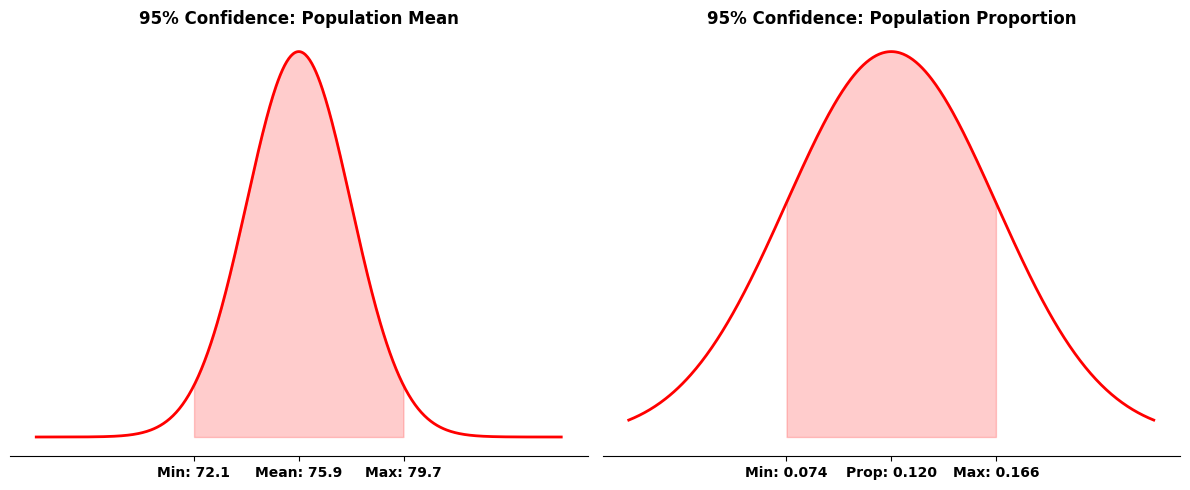

In [195]:
#data
n = 50
df = n - 1
confidence = 0.975

#population mean
mean = 75.9
s = 13.3854 #standard deviation

#calculing t critical
t_critical = stats.t.ppf(confidence, df)

#interval calculation
mean_error = t_critical * (s / math.sqrt(n))

mean_inf_interval = mean - mean_error
mean_sup_interval = mean + mean_error

#population proportion
prop = 0.120

#calculing z critical
z_critical = stats.norm.ppf(confidence)

#interval calculation
prop_error =  (math.sqrt((prop * (1 - prop)) / n))

prop_inf_interval = prop - prop_error
prop_sup_interval = prop + prop_error

#prints
print(f"Mean error: {mean_error:.2f}")
print(f"Mean error interval: [{mean_inf_interval:.1f} a {mean_sup_interval:.1f}]\n")
print(f"Proportion error: {prop_error:.3f}")
print(f"Proportion error interval: [{prop_inf_interval:.3f} a {prop_sup_interval:.3f}]")

#plotting
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

#population mean
x_m = np.linspace(mean - 2.5*mean_error, mean + 2.5*mean_error, 500)
y_m = stats.norm.pdf(x_m, mean, (s / math.sqrt(n)))

ax1.plot(x_m, y_m, color='red', lw=2)
ax1.fill_between(x_m, y_m, where=((x_m >= mean_inf_interval) & (x_m <= mean_sup_interval)), 
                 color='red', alpha=0.2)

ax1.set_xticks([mean_inf_interval, mean, mean_sup_interval])
ax1.set_xticklabels([f'Min: {mean_inf_interval:.1f}', f'Mean: {mean:.1f}', f'Max: {mean_sup_interval:.1f}'], 
                    fontsize=10, fontweight='bold')
ax1.tick_params(axis='x', labelbottom=True)

ax1.set_title("95% Confidence: Population Mean", fontsize=12, fontweight='bold')
ax1.set_yticks([])
ax1.spines['bottom'].set_visible(True)
for s_name in ['top', 'left', 'right']: ax1.spines[s_name].set_visible(False)

#population proportion
x_p = np.linspace(prop - 2.5*prop_error, prop + 2.5*prop_error, 500)
y_p = stats.norm.pdf(x_p, prop, prop_error)

ax2.plot(x_p, y_p, color='red', lw=2)
ax2.fill_between(x_p, y_p, where=((x_p >= prop_inf_interval) & (x_p <= prop_sup_interval)), 
                 color='red', alpha=0.2)

ax2.set_xticks([prop_inf_interval, prop, prop_sup_interval])
ax2.set_xticklabels([f'Min: {prop_inf_interval:.3f}', f'Prop: {prop:.3f}', f'Max: {prop_sup_interval:.3f}'], 
                    fontsize=10, fontweight='bold')
ax2.tick_params(axis='x', labelbottom=True)

ax2.set_title("95% Confidence: Population Proportion", fontsize=12, fontweight='bold')
ax2.set_yticks([])
ax2.spines['bottom'].set_visible(True)
for s_name in ['top', 'left', 'right']: ax2.spines[s_name].set_visible(False)

#plot
plt.tight_layout()
plt.show()

---

# F

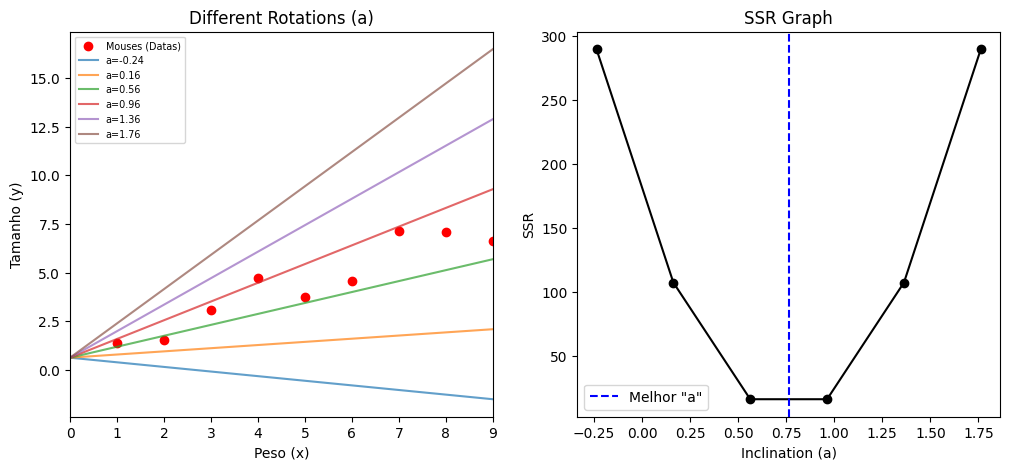

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.882
Model:                            OLS   Adj. R-squared:                  0.865
Method:                 Least Squares   F-statistic:                     52.23
Date:                Wed, 28 Jan 2026   Prob (F-statistic):           0.000173
Time:                        21:40:30   Log-Likelihood:                -9.8246
No. Observations:                   9   AIC:                             23.65
Df Residuals:                       7   BIC:                             24.04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.6244      0.594      1.051      0.3

In [ ]:
#data
np.random.seed(42)
x = np.array([1, 2, 3, 4, 5, 6, 7, 8, 9]).reshape(-1, 1)
y = 0.1 + 0.78 * x.flatten() + np.random.normal(0, 1.0, size=len(x))

#finding b (intercept), and a (inclination)
model = LinearRegression().fit(x, y)
ideal_b = model.intercept_
ideal_a = model.coef_[0]

#statsmodels
x_const = sm.add_constant(x) 
report = sm.OLS(y, x_const).fit()

#trying 6 differents a's
slopes = np.linspace(ideal_a - 1, ideal_a + 1, 6)
ssr_list = []
r2_list = []

#plot
plt.figure(figsize=(12, 5))

#graph 1 - lines 
plt.subplot(1, 2, 1)
plt.scatter(x, y, color='red', label='Mouses (Datas)')

x_plot = np.linspace(0, 9, 100) 
for a in slopes: #lines
    predicted_y_plot = ideal_b + a * x_plot
    plt.plot(x_plot, predicted_y_plot, label=f'a={a:.2f}', alpha=0.7)
    
    predicted_y_calc = ideal_b + a * x.flatten()
    
    ssr_list.append(np.sum((y - predicted_y_calc)**2))
    r2_list.append(r2_score(y, predicted_y_calc))

plt.title("Different Rotations (a)")
plt.xlabel("Weight")
plt.ylabel("Size")
plt.xlim(0, 9)
plt.legend(fontsize='x-small')

#graph 2 - SSR
plt.subplot(1, 2, 2)
plt.plot(slopes, ssr_list, 'o-k')
plt.axvline(ideal_a, color='blue', linestyle='--', label='Melhor "a"')
plt.title("SSR Graph")
plt.xlabel("Inclination (a)")
plt.ylabel("SSR")
plt.legend()
plt.show()

#prints
#ideal model
print(report.summary())

print("\n" + "="*65)
print("Ideal Model Analysis:")
print(f"-> R-squared:         {report.rsquared:.4f}")
print(f"-> Adj. R-squared:    {report.rsquared_adj:.4f}")
print(f"-> F-statistic:       {report.fvalue:.4f}")
print(f"-> Prob (F-statistic):{report.f_pvalue:.4e}")
print(f"-> P-value (Slope a): {report.pvalues[1]:.4e}")
print("="*65)

#A's vs Ideal Model
print("\n" + "="*65)
print(f'{"COMPARISON: ROTATIONS vs. IDEAL (MAX R²)":^65}')
print("="*65)
print(f"{'Inclination (a)':<20} | {'R²':<20} | {'Status'}")
print("-" * 65)

#A's status
melhor_r2 = report.rsquared
for i, a in enumerate(slopes):
    #comparation
    if abs(a - ideal_a) < 0.1:
        status = "CLOSE TO IDEAL"
    else:
        status = "SUB-OPTIMAL"
    
    print(f"{a:<20.4f} | {r2_list[i]:<20.4f} | {status}")

#ideal A
print("-" * 65)
print(f"{ideal_a:<20.4f} | {melhor_r2:<20.4f} | IDEAL (SKLEARN)")
print("="*65)



---

# G

---

# H